This notebook is used to get the Experiment results for the dropclass-publication

# Prerequisites

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
# import new main notebook
df_main = pd.read_excel('../data/df_main_edited.xlsx')
display(df_main.head())
df_main.info()

,test,one_drop,splashing,breaking_up,net_impact,rebound,voltage,long_impulse_duration,height,inclination,...,Re,We,We_Re,particle_droplet_diameter_ratio,particle_diameter_cat,breaking_up_receding,splashing_semi,rebound_total,rebound_true,jet_ejection
0,3,1,1,0,0,0,105.0,10,0.8,0,...,1492.516020,1492.302356,240.108847,0.013301,small,0,0,0,0,0
1,4,1,1,0,0,0,105.0,10,0.8,0,...,1492.516020,1492.302356,240.108847,0.013301,small,0,0,0,0,0
2,5,1,1,0,0,0,105.0,10,0.8,0,...,1492.516020,1492.302356,240.108847,0.013301,small,0,0,0,0,0
3,7,0,1,0,0,0,105.0,10,0.8,0,...,1435.111557,1434.906112,233.148786,0.013833,small,0,0,0,0,0
4,8,0,1,0,0,0,105.0,10,0.8,0,...,1435.111557,1434.906112,233.148786,0.013833,small,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   one_drop                         372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   breaking_up                      372 non-null    int64  
 4   net_impact                       372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   voltage                          372 non-null    float64
 7   long_impulse_duration            372 non-null    int64  
 8   height                           372 non-null    float64
 9   inclination                      372 non-null    int64  
 10  droplet_diameter                 372 non-null    float64
 11  liquid_density                   372 non-null    int64  
 12  surface_tension       

In [3]:
df_main['particle_density'] = df_main['liquid_density'] * df_main['particle_liquid_density_ratio']
df_main['particle_density'] = df_main['particle_density'].round(0)
df_main['particle_density'].value_counts()

particle_density
1000.0    183
1200.0    147
450.0      23
2200.0     19
Name: count, dtype: int64

$velocity = \sqrt{2g\cdot height}$

$Re=\frac{velocity \cdot droplet\_diameter \cdot liquid\_density}{viscosity}$

$We=\frac{velocity^2 \cdot droplet\_diameter \cdot liquid\_density}{surface\_tension}$

$We\_Re = We^{1/2}Re^{1/4}$

particle_droplet_diameter_ratio = particle_mean_diameter / droplet_diameter

particle_liquid_density_ratio = particle_density / liquid_density

*Params above were checked*

## Labels combination
- combine - splashing, splashing_semi 
- combine - jet_ejection, rebound

In [4]:
def get_splashing_combined(row):
    if row['splashing'] == 1:
        return 2
    if row['splashing_semi'] == 1:
        return 1
    return 0

df_main['splashing_combined'] = df_main.apply(get_splashing_combined, axis=1)
df_main['splashing_combined'].value_counts()

splashing_combined
2    174
0    153
1     45
Name: count, dtype: int64

In [5]:
def get_rebound_combined(row):
    if row['rebound_true'] == 1:
        return 2
    if row['jet_ejection'] == 1:
        return 1
    return 0

df_main['rebound_combined'] = df_main.apply(get_rebound_combined, axis=1)
df_main['rebound_combined'].value_counts()

rebound_combined
0    273
1     55
2     44
Name: count, dtype: int64

## Drop unnecessary columns and rename others

In [6]:
# Drop unused columns
drop_columns = ['one_drop', 'splashing', 'splashing_semi', 'breaking_up', 'rebound', 'rebound_total', 'rebound_true', 'jet_ejection', 'voltage', 'long_impulse_duration', 'long_impulse_dur_binary', 'height', 'particle_diameter_cat']
df = df_main.drop(drop_columns, axis=1)

# Rename columns
rename_columns = {
    'splashing_combined': 'splashing',
    'breaking_up_receding': 'breaking_up',
    'rebound_combined': 'rebound',
}

df = df.rename(rename_columns, axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   net_impact                       372 non-null    int64  
 2   inclination                      372 non-null    int64  
 3   droplet_diameter                 372 non-null    float64
 4   liquid_density                   372 non-null    int64  
 5   surface_tension                  372 non-null    float64
 6   viscosity                        372 non-null    float64
 7   particle_mean_diameter           372 non-null    float64
 8   particle_liquid_density_ratio    372 non-null    float64
 9   volume_fraction                  372 non-null    float64
 10  wettability                      372 non-null    object 
 11  roughness                        372 non-null    float64
 12  roughness_binary      

## Reorder columns

18 columns: 'test', [labels] - 6, [features_original] - 11

7 columns: aggregated

In [7]:
labels = ['net_impact', 'splashing', 'breaking_up', 'rebound']
# do not forget 'test'
features_original = ['wettability', 'roughness', 'liquid_density', 'surface_tension', 'viscosity', 'particle_mean_diameter', 'particle_density', 'volume_fraction', 'droplet_diameter', 'velocity', 'inclination']

features_aggregated = ['roughness_binary', 'particle_liquid_density_ratio', 'volume_fraction_binary', 'particle_droplet_diameter_ratio', 'Re', 'We', 'We_Re']

columns_sorted = ['test'] + features_original + features_aggregated + labels
len(columns_sorted)

23

In [8]:
df = df[columns_sorted]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   wettability                      372 non-null    object 
 2   roughness                        372 non-null    float64
 3   liquid_density                   372 non-null    int64  
 4   surface_tension                  372 non-null    float64
 5   viscosity                        372 non-null    float64
 6   particle_mean_diameter           372 non-null    float64
 7   particle_density                 372 non-null    float64
 8   volume_fraction                  372 non-null    float64
 9   droplet_diameter                 372 non-null    float64
 10  velocity                         372 non-null    float64
 11  inclination                      372 non-null    int64  
 12  roughness_binary      

# Research

Let us plot different scatter-plots with Re_We at the bottom

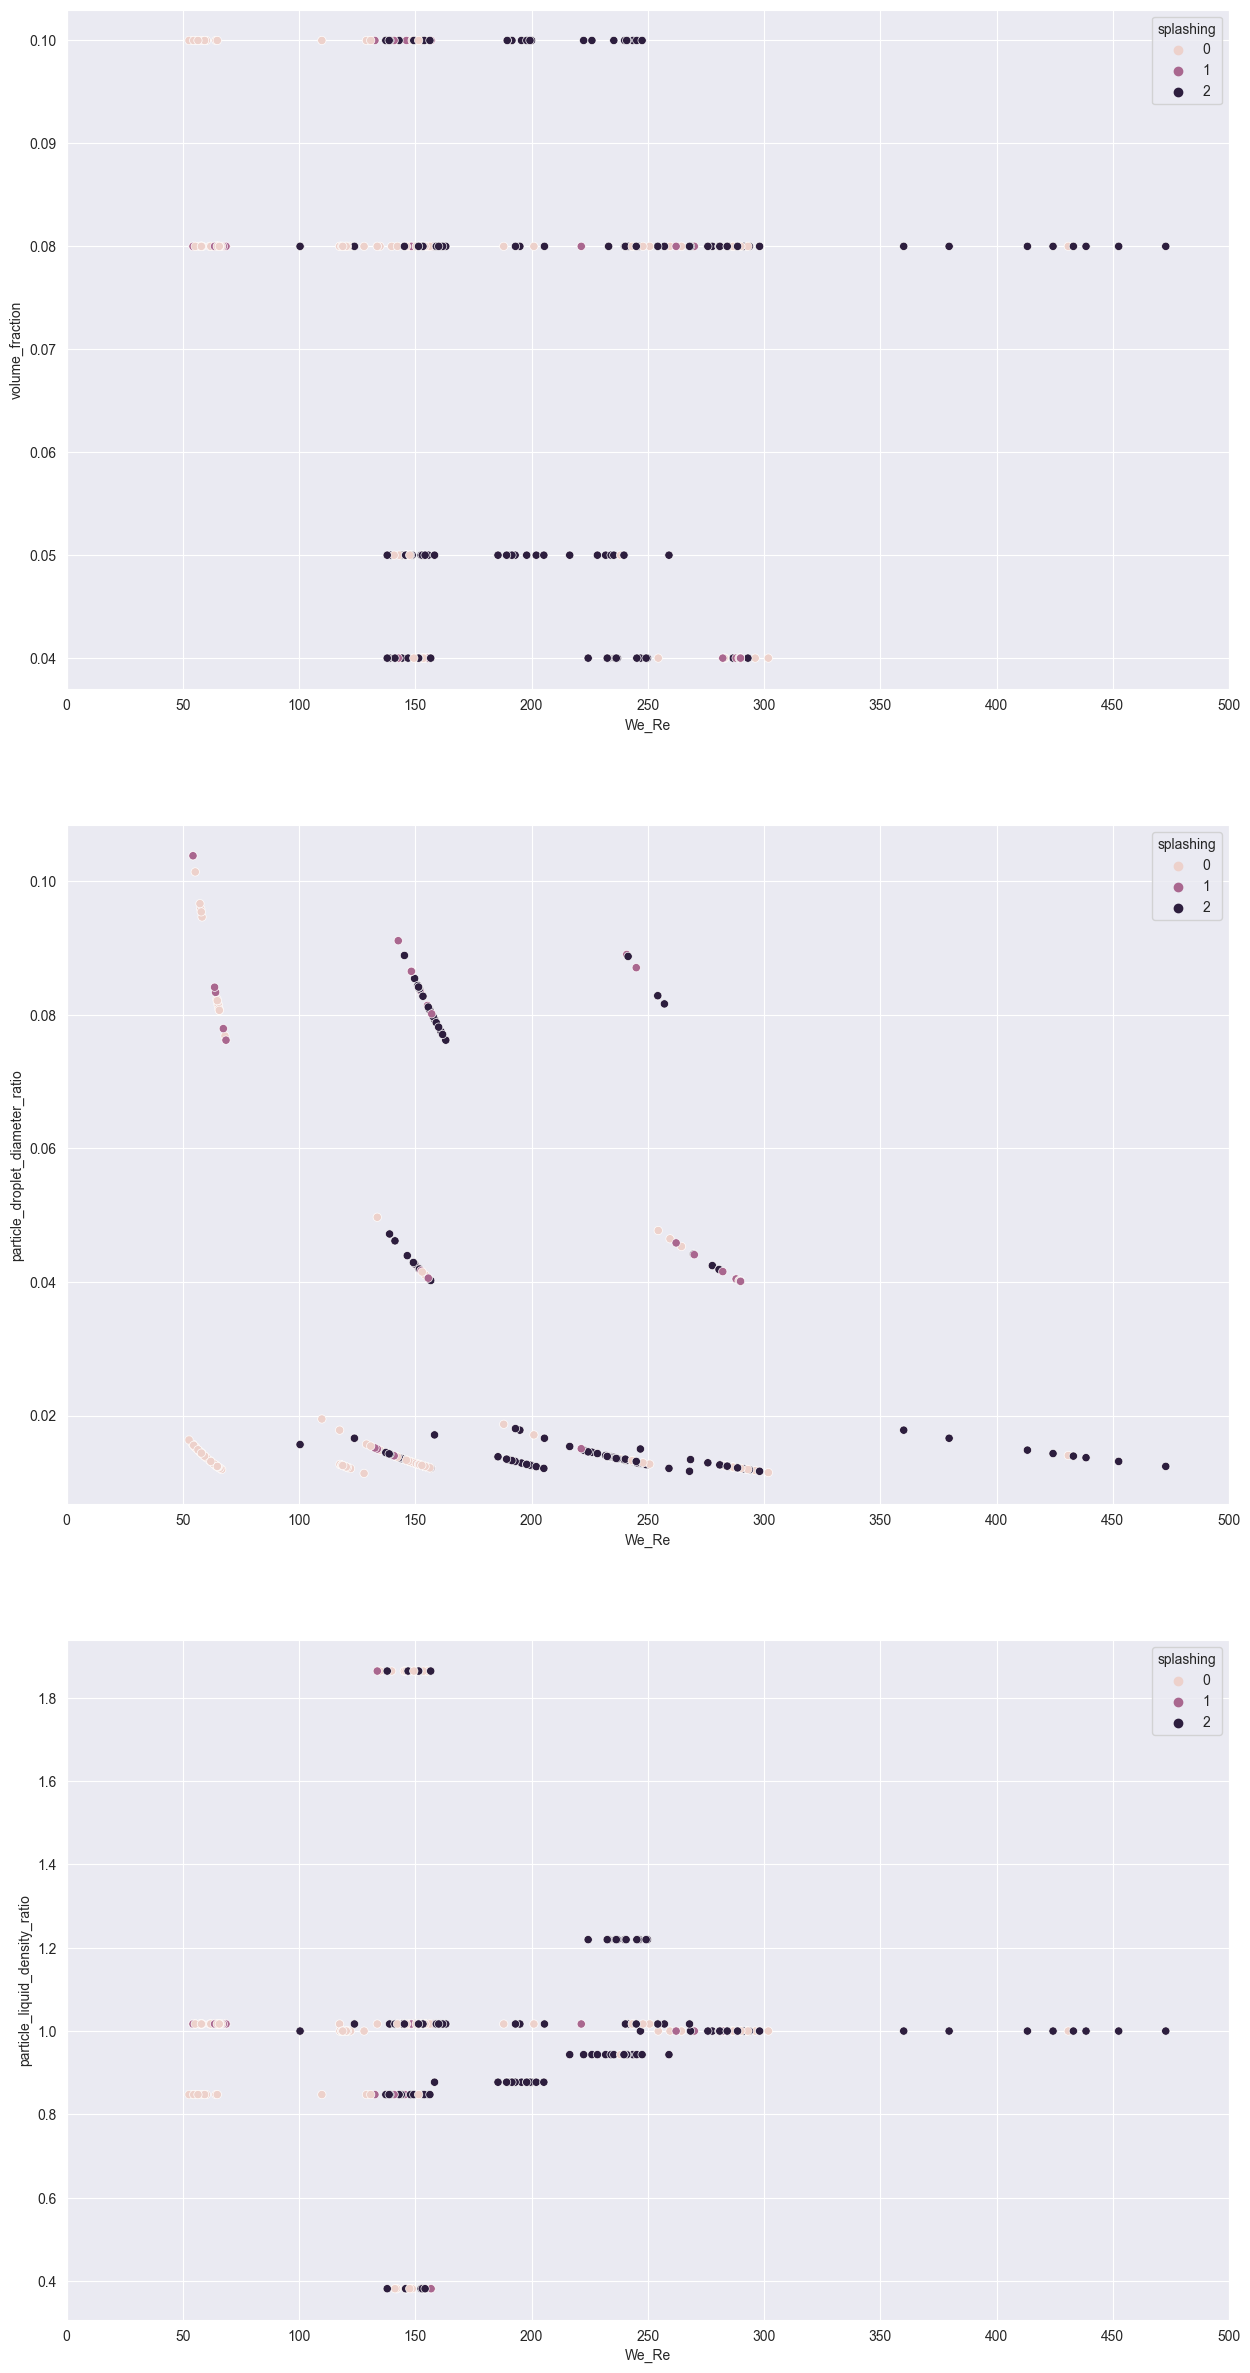

In [41]:
fig, (ax_volume_fraction, ax_diam_ratio, ax_density_ratio) = plt.subplots(3, 1, figsize=(15,30))
sns.scatterplot(data=df, x='We_Re', y='volume_fraction', hue='splashing', ax=ax_volume_fraction)
sns.scatterplot(data=df, x='We_Re', y='particle_droplet_diameter_ratio', hue='splashing', ax=ax_diam_ratio)
sns.scatterplot(data=df, x='We_Re', y='particle_liquid_density_ratio', hue='splashing', ax=ax_density_ratio)

axes = (ax_volume_fraction, ax_diam_ratio, ax_density_ratio)

for ax in axes:
    ax.set_xticks(list(np.arange(0, 510, 50)));

<Axes: xlabel='splashing', ylabel='We_Re'>

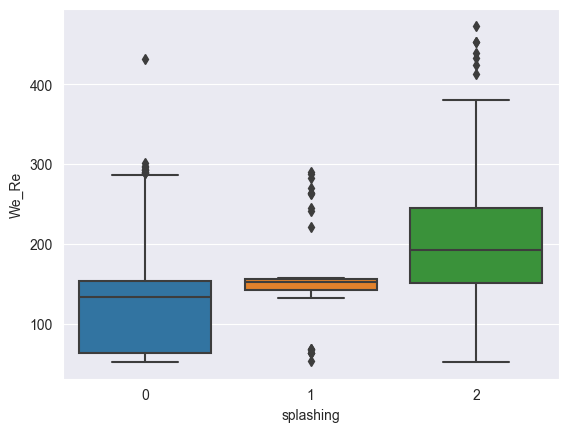

In [42]:
sns.boxplot(data=df, x='splashing', y='We_Re')

<Axes: xlabel='rebound', ylabel='We_Re'>

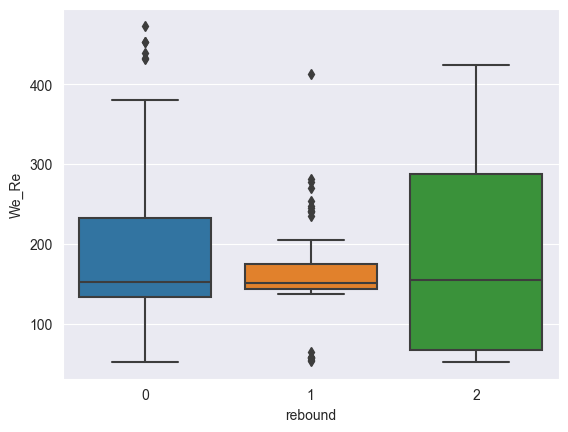

In [45]:
sns.boxplot(data=df, x='rebound', y='We_Re')

Idea: drop outliers!

<Axes: xlabel='breaking_up', ylabel='We_Re'>

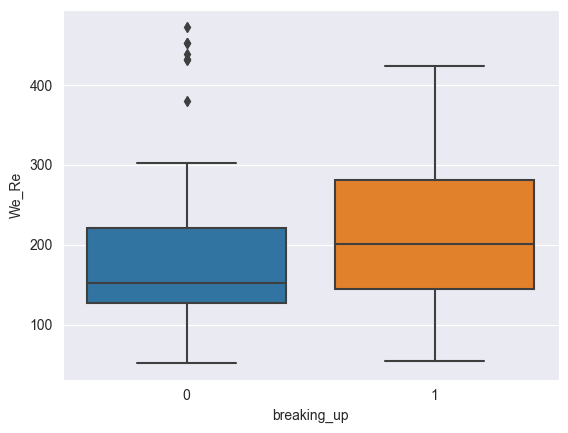

In [43]:
sns.boxplot(data=df, x='breaking_up', y='We_Re')

Let us consider duplicates. Do they have the same labels?